# Face connections: the seam in `U`, `vg` and `okubo_weiss`

A one-cell stripe appears at the rotated LLC face boundaries (most
visibly near 142.5 E) in every field built from a staggered vector pair
that is then rotated to east/north. This notebook shows where it comes
from, fixes it, and checks each affected field against a control.

Runs on real OSN surface data, two faces at a time, with an optional
full `generate_global` pass at the end.


In [1]:
import warnings
from contextlib import contextmanager

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrow, Polygon

import dbof.preprocessing.calculate_fields as cf
import dbof.utils.native_gradient as ng
from dbof.global_dataset_creation.data_sources import OSN_ENDPOINT
from dbof.global_dataset_creation.grid_setup import set_up_grid
from dbof.llc4320_ingestion.grid import face_connections

warnings.filterwarnings("ignore")

#: Face 4's X-upper neighbour is face 8, reached along face 8's Y axis --
#: a rotated connection, so this is where the halo goes wrong.
FACE_A, FACE_B = 4, 8
DATE = "2012-11-09 12:00:00"

print("face 4 connections:", face_connections["face"][FACE_A])
print("face 8 connections:", face_connections["face"][FACE_B])

face 4 connections: {'X': ((1, 'X', False), (8, 'Y', False)), 'Y': ((3, 'Y', False), (5, 'Y', False))}
face 8 connections: {'X': ((7, 'X', False), (9, 'X', False)), 'Y': ((4, 'X', False), (11, 'Y', False))}


## 1. What the rotation does to the model axes

Each LLC face carries its own model `x`/`y`. On faces 0-5 they line up
roughly with east/north; on faces 7-12 they are turned 90 degrees
clockwise, so `i` runs south and `j` runs east. `U` lives on the west
cell edge (`i_g`), `V` on the south edge (`j_g`), so when the grid
turns, so do they.

Face 4's upper `X` edge borders face 8 **along face 8's `Y` axis**.
Stepping across that edge, model-x becomes model-y: the neighbour value
that continues face 4's `U` is face 8's `V`, not its `U`.


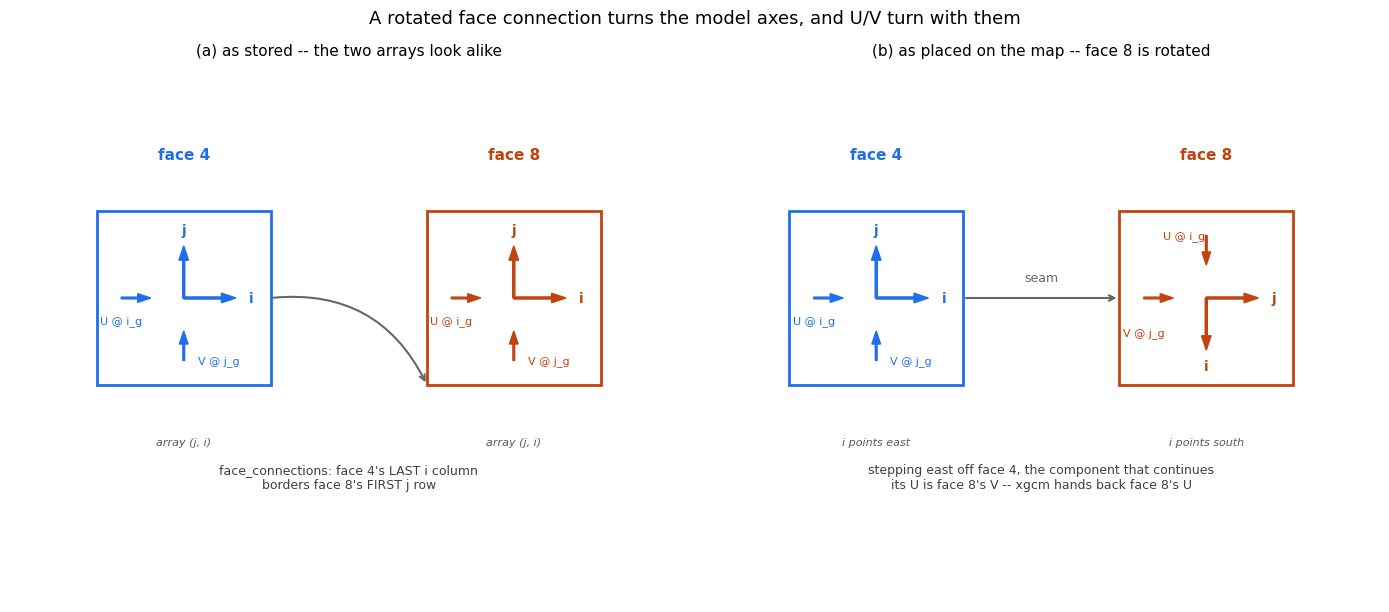

In [2]:
def _draw_face(ax, centre, size, angle, label, color, note=None):
    """Draw one face box with its model axes and its U/V points.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    centre : tuple of float
        Box centre.
    size : float
        Box side length.
    angle : float
        Rotation of the whole face, degrees anticlockwise.
    label : str
        Face label, drawn above the box.
    color : str
    note : str, optional
        Small caption under the box.

    Generated by LH and Claude
    """
    rad = np.deg2rad(angle)
    ex = np.array([np.cos(rad), np.sin(rad)])       # model +x  (i)
    ey = np.array([-np.sin(rad), np.cos(rad)])      # model +y  (j)
    centre = np.asarray(centre, float)
    half = size / 2

    corners = [centre + sx * ex * half + sy * ey * half
               for sx, sy in ((-1, -1), (1, -1), (1, 1), (-1, 1))]
    ax.add_patch(Polygon(corners, closed=True, fill=False,
                         edgecolor=color, lw=2))
    ax.text(*(centre + np.array([0, size * 0.78])), label, color=color,
            ha="center", va="bottom", fontsize=11, fontweight="bold")
    if note:
        ax.text(*(centre - np.array([0, size * 0.80])), note, color="0.35",
                ha="center", va="top", fontsize=8, style="italic")

    arr = size * 0.30
    ax.add_patch(FancyArrow(*centre, *(ex * arr), width=size * 0.012,
                            head_width=size * 0.055,
                            length_includes_head=True, color=color))
    ax.text(*(centre + ex * arr * 1.30), "i", color=color, ha="center",
            va="center", fontsize=10, fontweight="bold")
    ax.add_patch(FancyArrow(*centre, *(ey * arr), width=size * 0.012,
                            head_width=size * 0.055,
                            length_includes_head=True, color=color))
    ax.text(*(centre + ey * arr * 1.30), "j", color=color, ha="center",
            va="center", fontsize=10, fontweight="bold")

    # U on the west cell edge (i_g), V on the south edge (j_g) -- west and
    # south in MODEL axes, so they turn with the face.
    u_pt = centre - ex * half * 0.72
    ax.add_patch(FancyArrow(*u_pt, *(ex * size * 0.17), width=size * 0.010,
                            head_width=size * 0.05,
                            length_includes_head=True, color=color))
    ax.text(*(u_pt - ey * size * 0.13), "U @ i_g", color=color,
            ha="center", va="center", fontsize=8)
    v_pt = centre - ey * half * 0.72
    ax.add_patch(FancyArrow(*v_pt, *(ey * size * 0.17), width=size * 0.010,
                            head_width=size * 0.05,
                            length_includes_head=True, color=color))
    ax.text(*(v_pt + ex * size * 0.20), "V @ j_g", color=color,
            ha="center", va="center", fontsize=8)


BLUE, RUST = "#1f6feb", "#c1440e"
fig, axes = plt.subplots(1, 2, figsize=(14, 6.4))

# (a) as stored: both faces are just (j, i) arrays and look identical
_draw_face(axes[0], (0.0, 0.0), 1.0, 0, "face 4", BLUE, "array (j, i)")
_draw_face(axes[0], (1.9, 0.0), 1.0, 0, "face 8", RUST, "array (j, i)")
axes[0].annotate("", xy=(1.40, -0.50), xytext=(0.50, 0.0),
                 arrowprops=dict(arrowstyle="->", lw=1.5, color="0.4",
                                 connectionstyle="arc3,rad=-0.35"))
axes[0].text(0.95, -0.95,
             "face_connections: face 4's LAST i column\n"
             "borders face 8's FIRST j row",
             ha="center", va="top", fontsize=9, color="0.25")
axes[0].set_title("(a) as stored -- the two arrays look alike",
                  fontsize=11)

# (b) as placed on the map: face 8 is turned, and its U turns with it
_draw_face(axes[1], (0.0, 0.0), 1.0, 0, "face 4", BLUE,
           "i points east")
_draw_face(axes[1], (1.9, 0.0), 1.0, -90, "face 8", RUST,
           "i points south")
axes[1].annotate("", xy=(1.40, 0.0), xytext=(0.50, 0.0),
                 arrowprops=dict(arrowstyle="->", lw=1.5, color="0.4"))
axes[1].text(0.95, 0.10, "seam", ha="center", fontsize=9, color="0.4")
axes[1].text(0.95, -0.95,
             "stepping east off face 4, the component that continues\n"
             "its U is face 8's V -- xgcm hands back face 8's U",
             ha="center", va="top", fontsize=9, color="0.25")
axes[1].set_title("(b) as placed on the map -- face 8 is rotated",
                  fontsize=11)

for ax in axes:
    ax.set_xlim(-1.0, 2.9)
    ax.set_ylim(-1.75, 1.35)
    ax.set_aspect("equal")
    ax.axis("off")
fig.suptitle("A rotated face connection turns the model axes, "
             "and U/V turn with them", fontsize=13)
fig.tight_layout()
plt.show()

## 2. The same two faces with real data, the old way

Load one OSN surface snapshot and move `U`/`V` to tracer points the way
the code did before the fix: each component interpolated on its own.
Then lay face 4 and face 8 side by side across their shared edge.

In [3]:
from dbof.cli.generate_global import load_snapshot

ds_grid, land_mask, grid = set_up_grid("OSN", None, endpoint_url=OSN_ENDPOINT)
ds_raw, ds_merge, iteration = load_snapshot(
    "OSN", DATE, ds_grid, ["Theta", "Salt", "Eta", "U", "V"],
    surface_only=False, data_source=None)
print(f"iteration {iteration};  U dims {ds_merge.U.dims}")

Opening 13 Kerchunk JSON files...
Parsing JSON metadata into Python dicts...
Creating lazy xarray datasets...
Computing delayed datasets...
Combining datasets by coordinates...
Dataset combined successfully.
iteration 1473984;  U dims ('face', 'j', 'i_g')


In [4]:
@contextmanager
def legacy_scalar_interp():
    """Restore the pre-fix behaviour inside this block.

    Replaces each paired helper with two independent scalar calls --
    what ``rotate_vector_to_geographic``, the Jacobian and the corner
    stencils used to do -- and masks the whole rotated rim, which is how
    the corner terms used to hide their bad halo.

    Generated by LH and Claude
    """
    import dbof.llc4320_ingestion.grid as gridmod

    real_mask = gridmod.face_seam_mask

    def legacy_mask(da, grid, width=1):
        """Mask EVERY unusable edge -- what the code did before."""
        return real_mask(da, grid, width, kind='all')

    def scalar_interp(x_component, y_component, grid):
        return (grid.interp(x_component, 'X', padding='fill'),
                grid.interp(y_component, 'Y', padding='fill'))

    def scalar_diff(x_component, y_component, grid):
        return (grid.diff(x_component, 'X', padding='fill'),
                grid.diff(y_component, 'Y', padding='fill'))

    def scalar_cross_diff(x_component, y_component, grid):
        return (grid.diff(x_component, 'Y', padding='fill'),
                grid.diff(y_component, 'X', padding='fill'))

    # The corner terms used to be padded one component at a time, and
    # the whole rotated rim was then NaN-ed rather than exchanged.
    replacements = {"interp_pair_to_center": scalar_interp,
                    "diff_pair_along_own_axis": scalar_diff,
                    "diff_pair_across_other_axis": scalar_cross_diff,
                    "face_seam_mask": legacy_mask}
    saved = []
    for mod in (gridmod, ng, cf):
        for name, repl in replacements.items():
            if hasattr(mod, name):
                saved.append((mod, name, getattr(mod, name)))
                setattr(mod, name, repl)
    try:
        yield
    finally:
        for mod, name, fn in saved:
            setattr(mod, name, fn)


def seam_pair(da, face_a=FACE_A, face_b=FACE_B):
    """Lay face_a and face_b side by side across their shared edge.

    The orientation of the neighbour is chosen empirically: of the four
    transposes/flips, keep the one whose joining column lands closest to
    face_a's, in longitude AND latitude.  Longitude alone cannot see a
    vertical flip here.  That is the rotation, measured rather than
    assumed.

    Parameters
    ----------
    da : xarray.DataArray
        Field with dims (face, j, i).
    face_a, face_b : int

    Returns
    -------
    numpy.ndarray
        2D array with the seam running down the middle.

    Generated by LH and Claude
    """
    a = np.asarray(da.isel(face=face_a))
    b = np.asarray(da.isel(face=face_b))
    lon_a = np.asarray(ds_grid.XC.isel(face=face_a))
    lon_b = np.asarray(ds_grid.XC.isel(face=face_b))
    lat_a = np.asarray(ds_grid.YC.isel(face=face_a))
    lat_b = np.asarray(ds_grid.YC.isel(face=face_b))

    best, best_jump = None, np.inf
    for name, fn in (("T", lambda z: z.T),
                     ("T+flipud", lambda z: np.flipud(z.T)),
                     ("T+fliplr", lambda z: np.fliplr(z.T)),
                     ("T+rot180", lambda z: np.flipud(np.fliplr(z.T)))):
        # distance between the two columns that end up adjacent
        jump = np.nanmedian(np.hypot(fn(lon_b)[:, 0] - lon_a[:, -1],
                                     fn(lat_b)[:, 0] - lat_a[:, -1]))
        print(f"    {name:10s} median gap across the join {jump:7.3f} deg")
        if jump < best_jump:
            best, best_jump = (name, fn), jump
    name, fn = best
    print(f"  neighbour orientation '{name}'")
    return np.concatenate([a, fn(b)], axis=1), a.shape[1]


def show_seam(arrays, titles, seam_col, suptitle, cmap="viridis",
              zoom=60, symmetric=False):
    """Plot each array with the seam marked, plus a zoom on the join.

    Parameters
    ----------
    arrays : list of numpy.ndarray
    titles : list of str
    seam_col : int
        Column index of the join.
    suptitle : str
    cmap : str
    zoom : int
        Half-width of the zoom window, in cells.
    symmetric : bool
        Centre the colour scale on zero.

    Generated by LH and Claude
    """
    n = len(arrays)
    fig, axes = plt.subplots(2, n, figsize=(6.2 * n, 8.4),
                             squeeze=False)
    finite = np.concatenate([a[np.isfinite(a)].ravel() for a in arrays])
    if symmetric:
        lim = np.nanpercentile(np.abs(finite), 99)
        kw = dict(vmin=-lim, vmax=lim, cmap="RdBu_r")
    else:
        kw = dict(vmin=np.nanpercentile(finite, 1),
                  vmax=np.nanpercentile(finite, 99), cmap=cmap)
    sl = slice(max(seam_col - zoom, 0), seam_col + zoom)
    for k, (arr, title) in enumerate(zip(arrays, titles)):
        axes[0][k].pcolormesh(arr, **kw)
        axes[0][k].axvline(seam_col, color="k", lw=0.6, ls="--")
        axes[0][k].set_title(title, fontsize=10)
        axes[1][k].pcolormesh(np.arange(sl.start, sl.stop),
                              np.arange(arr.shape[0]), arr[:, sl], **kw)
        axes[1][k].axvline(seam_col, color="k", lw=0.6, ls="--")
        axes[1][k].set_title(f"{title} -- zoom on the join", fontsize=9)
    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    plt.show()


    T          median gap across the join  36.593 deg
    T+flipud   median gap across the join   0.021 deg
    T+fliplr   median gap across the join 272.468 deg
    T+rot180   median gap across the join 270.000 deg
  neighbour orientation 'T+flipud'


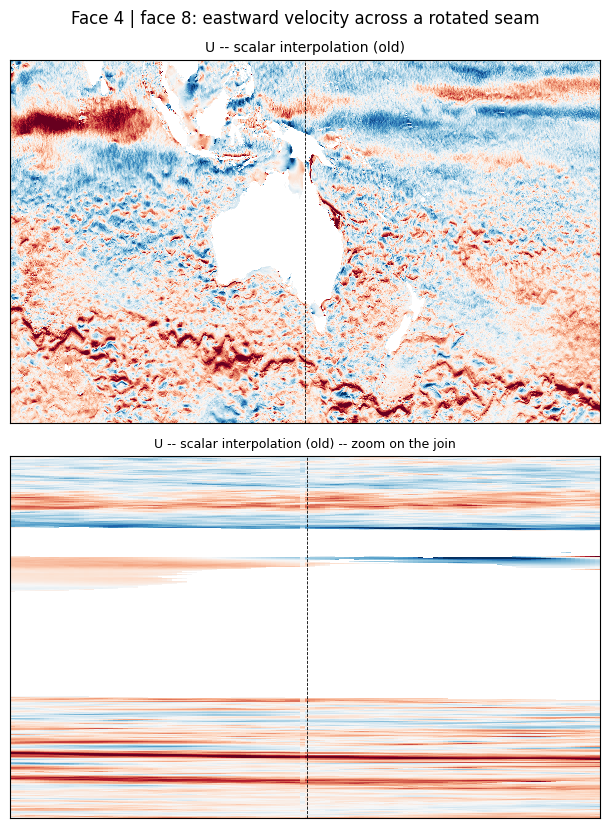

In [5]:
with legacy_scalar_interp():
    u_old, v_old = cf.geographic_velocity(ds_merge, grid)
u_old = u_old.compute()

panel_old, seam_col = seam_pair(u_old)
show_seam([panel_old], ["U -- scalar interpolation (old)"], seam_col,
          "Face 4 | face 8: eastward velocity across a rotated seam",
          symmetric=True)

## 3. The fix

`interp_pair_to_center` hands both components to xgcm together, so the
halo at a rotated connection is built from the partner. Same call,
same data, one line different.

    T          median gap across the join  36.593 deg
    T+flipud   median gap across the join   0.021 deg
    T+fliplr   median gap across the join 272.468 deg
    T+rot180   median gap across the join 270.000 deg
  neighbour orientation 'T+flipud'


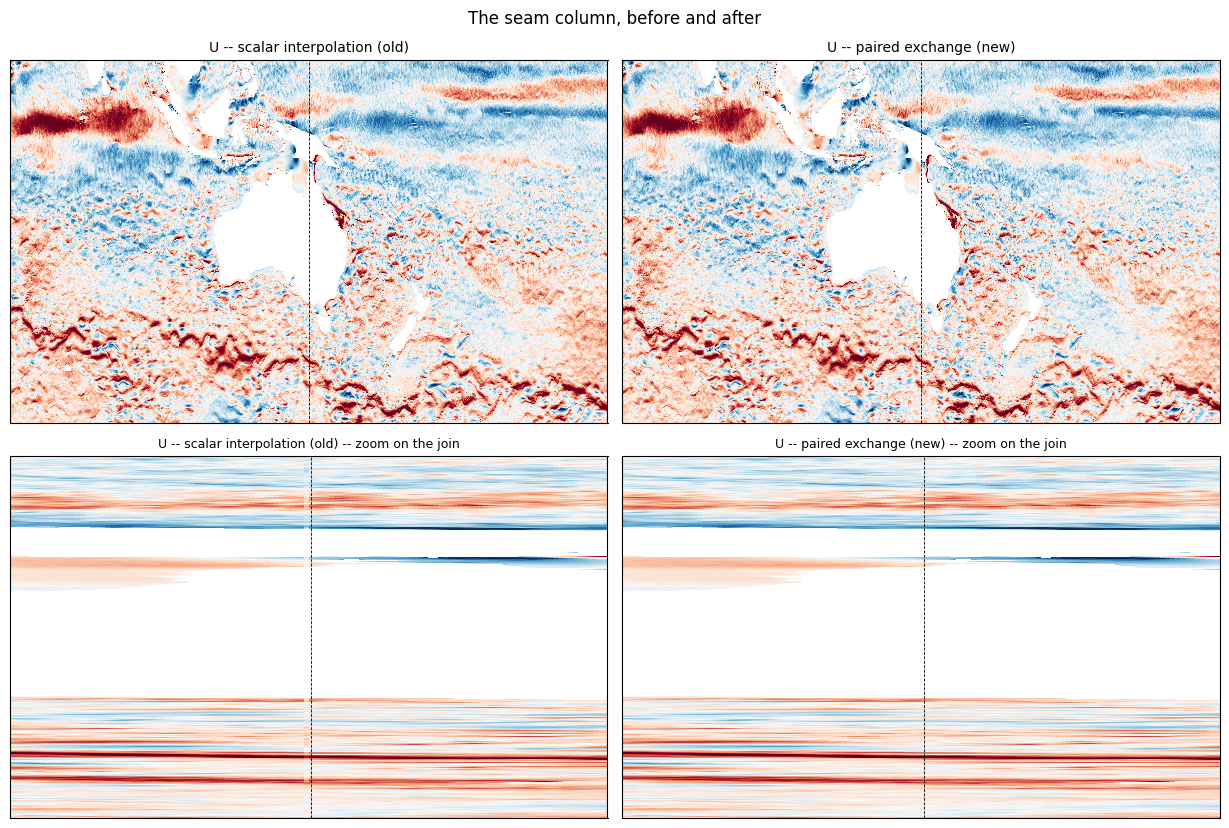

columns that changed: [4319]  (seam is at 4320)
largest change: 0.3420 m/s


In [14]:
from dbof.llc4320_ingestion.grid import invalid_seam_edges

u_new, v_new = cf.geographic_velocity(ds_merge, grid)
u_new = u_new.compute()

panel_new, _ = seam_pair(u_new)
show_seam([panel_old, panel_new],
          ["U -- scalar interpolation (old)", "U -- paired exchange (new)"],
          seam_col, "The seam column, before and after", symmetric=True)

diff = np.abs(panel_new - panel_old)
cols = np.flatnonzero(np.nanmax(diff, axis=0) > 0)
print(f"columns that changed: {cols}  (seam is at {seam_col})")
print(f"largest change: {np.nanmax(diff):.4f} m/s")

### Which fields this reaches

Any pair that is interpolated to centres and then **rotated** with
CS/SN carries the error into its output. Pairs that are combined as a
sum of squares are rotation-invariant and absorb it.

In [15]:
AFFECTED = {
    "U, V":                       "rotate_vector_to_geographic",
    "oceTAUX, oceTAUY":           "rotate_vector_to_geographic",
    "strain_n, strain_s":         "calculate_jacobian",
    "divergence":                 "calculate_jacobian",
    "relative_vorticity":         "calculate_jacobian",
    "rossby_number":              "calculate_jacobian",
    "ug, vg":                     "calculate_native_gradient_tracer",
    "frontogenesis_*":            "calculate_native_gradient_tracer",
    "okubo_weiss, strain_mag":    "calculate_native_strain_vorticity",
}
UNAFFECTED = {
    "Theta, Salt, Eta, buoyancy": "no stencil at all",
    "gradb2, gradtheta2, ...":    "calculate_grad_squared_tracer (invariant)",
    "turner_angle":               "calculate_grad_dot_tracer (invariant)",
}
print("AFFECTED")
for k, v in AFFECTED.items():
    print(f"  {k:28s} <- {v}")
print("\nNOT AFFECTED")
for k, v in UNAFFECTED.items():
    print(f"  {k:28s} <- {v}")

edges = invalid_seam_edges()
rot = [e for e in sorted(edges)
       if face_connections["face"][e[0]][e[1]][0 if e[2] == "lower" else 1]
       is not None]
print(f"\nseam edges that cannot be copied straight: {len(edges)} of 52 "
      f"({len(rot)} rotated, {len(edges) - len(rot)} open domain edges)")
print("okubo_weiss / strain_mag reach the same way: their corner stencils")
print("move each component across the OTHER axis, so they pair too.")
print("What stays NaN is the open domain edges -- no neighbour to ask.")

AFFECTED
  U, V                         <- rotate_vector_to_geographic
  oceTAUX, oceTAUY             <- rotate_vector_to_geographic
  strain_n, strain_s           <- calculate_jacobian
  divergence                   <- calculate_jacobian
  relative_vorticity           <- calculate_jacobian
  rossby_number                <- calculate_jacobian
  ug, vg                       <- calculate_native_gradient_tracer
  frontogenesis_*              <- calculate_native_gradient_tracer
  okubo_weiss, strain_mag      <- calculate_native_strain_vorticity

NOT AFFECTED
  Theta, Salt, Eta, buoyancy   <- no stencil at all
  gradb2, gradtheta2, ...      <- calculate_grad_squared_tracer (invariant)
  turner_angle                 <- calculate_grad_dot_tracer (invariant)

seam edges that cannot be copied straight: 20 of 52 (16 rotated, 4 open domain edges)
okubo_weiss / strain_mag reach the same way: their corner stencils
move each component across the OTHER axis, so they pair too.
What stays NaN is the op

## 4. Every affected field, old vs new, with a control

`gradb2` is the control: it sums squares instead of rotating, so it
should be untouched to the last bit.

Two cells: the interpolation-path fields first, then `okubo_weiss` and
`strain_mag` on their own, because those carry the corner-stencil
defect and are the ones to re-run if that gets fixed.

In [16]:
def both_ways(fn):
    """Run *fn(ds_merge, grid)* with the old and the new exchange.

    Parameters
    ----------
    fn : callable
        Takes ``(ds_merge, grid)``, returns a DataArray.

    Returns
    -------
    (numpy.ndarray, numpy.ndarray, int)
        Old panel, new panel, seam column.

    Generated by LH and Claude
    """
    with legacy_scalar_interp():
        old = fn(ds_merge, grid).compute()
    new = fn(ds_merge, grid).compute()
    p_old, col = seam_pair(old)
    p_new, _ = seam_pair(new)
    return p_old, p_new, col


def run_fields(fields):
    """Plot old vs new for each field and print a change summary.

    Parameters
    ----------
    fields : dict
        Name -> callable taking ``(ds_merge, grid)``.

    Returns
    -------
    dict
        Name -> (cells changed, extra NaNs).

    Generated by LH and Claude
    """
    summary = {}
    for name, fn in fields.items():
        print(f"\n=== {name} ===")
        p_old, p_new, col = both_ways(fn)
        d = np.abs(p_new - p_old)
        changed = int(np.count_nonzero(np.nan_to_num(d) > 0))
        nan_new = int(np.isnan(p_new).sum() - np.isnan(p_old).sum())
        summary[name] = (changed, nan_new)
        print(f"  cells changed: {changed};  extra NaNs: {nan_new}")
        show_seam([p_old, p_new], [f"{name} -- old", f"{name} -- new"], col,
                  f"{name}: face {FACE_A} | face {FACE_B}",
                  symmetric=name not in ("strain_mag", "gradb2 (CONTROL)"))

    print("\n" + "=" * 58)
    print(f"{'field':22s} {'cells changed':>14s} {'extra NaNs':>12s}")
    for name, (changed, nan_new) in summary.items():
        print(f"{name:22s} {changed:>14d} {nan_new:>12d}")
    return summary



In [ ]:
# Fields fixed by handing xgcm both components (interpolation path).
FIELDS = {
    "U (eastward)":       lambda d, g: cf.geographic_velocity(d, g)[0],
    "vg (geostrophic)":   lambda d, g: cf.geostrophic_velocity(d, g)[1],
    "relative_vorticity": cf.relative_vorticity,
    "divergence":         cf.divergence,
    "gradb2 (CONTROL)":   cf.grad_b2,
}

run_fields(FIELDS)
print("gradb2 must read 0 / 0 -- it is rotation-invariant.")


=== okubo_weiss ===
    T          median gap across the join  36.593 deg
    T+flipud   median gap across the join   0.021 deg
    T+fliplr   median gap across the join 272.468 deg
    T+rot180   median gap across the join 270.000 deg
  neighbour orientation 'T+flipud'
    T          median gap across the join  36.593 deg
    T+flipud   median gap across the join   0.021 deg
    T+fliplr   median gap across the join 272.468 deg
    T+rot180   median gap across the join 270.000 deg
  neighbour orientation 'T+flipud'
  cells changed: 0;  extra NaNs: 7252


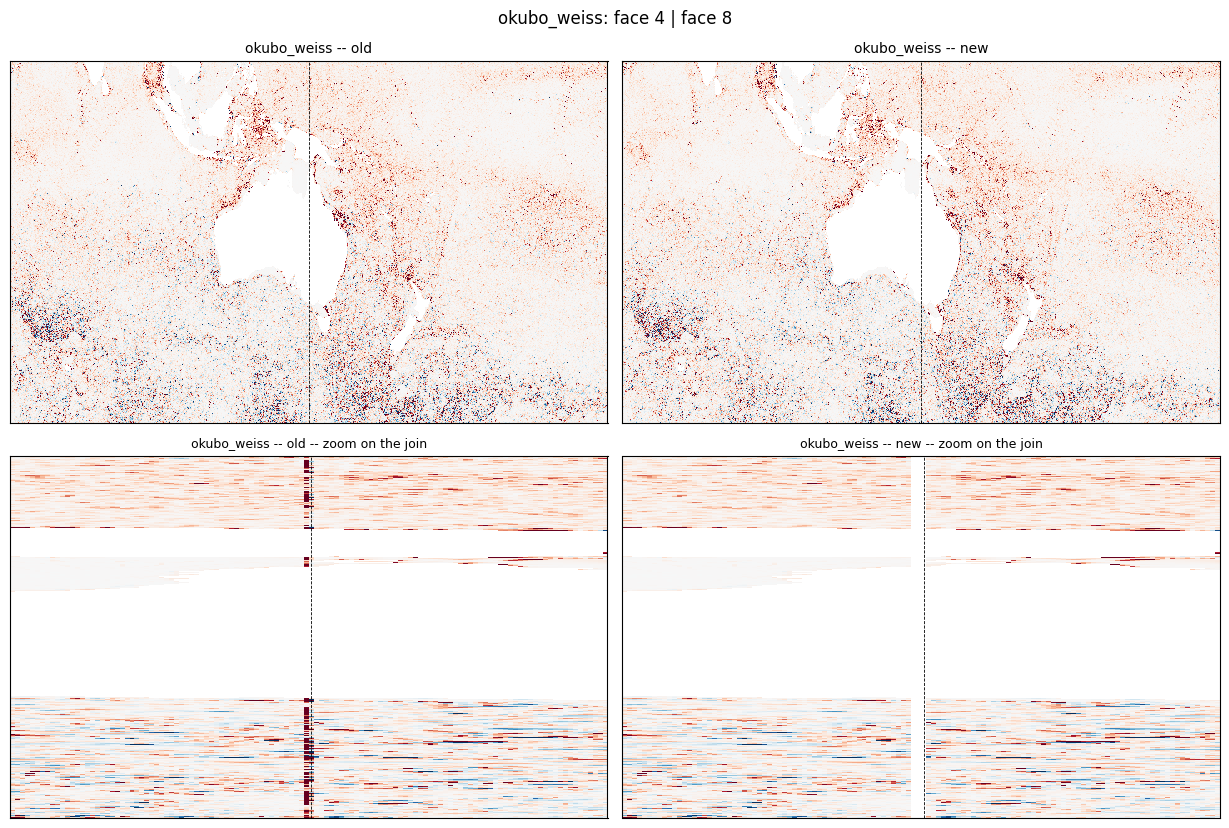


=== strain_mag ===
    T          median gap across the join  36.593 deg
    T+flipud   median gap across the join   0.021 deg
    T+fliplr   median gap across the join 272.468 deg
    T+rot180   median gap across the join 270.000 deg
  neighbour orientation 'T+flipud'
    T          median gap across the join  36.593 deg
    T+flipud   median gap across the join   0.021 deg
    T+fliplr   median gap across the join 272.468 deg
    T+rot180   median gap across the join 270.000 deg
  neighbour orientation 'T+flipud'
  cells changed: 0;  extra NaNs: 7252


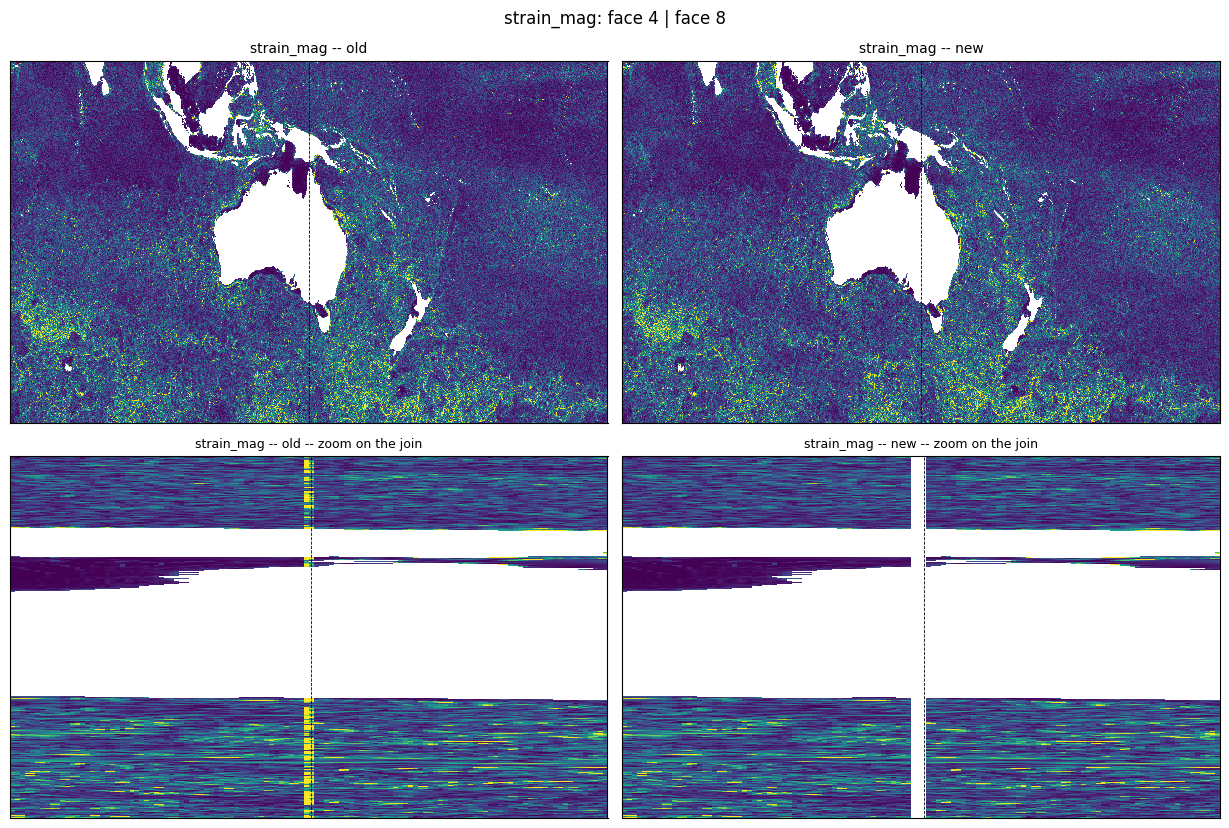


field                   cells changed   extra NaNs
okubo_weiss                         0         7252
strain_mag                          0         7252


{'okubo_weiss': (0, 7252), 'strain_mag': (0, 7252)}

In [17]:
# The corner-stencil fields, kept separate: they come through a
# different route -- each component is moved across the OTHER axis, so
# they need the same pairing (measured in
# dev/verify_corner_seam_exchange.py: 6.5e6x the interior error before,
# 13x after).  "new" should both change values AND lose most of its NaN
# rim; what stays NaN is the four open domain edges.
FIELDS_CORNER = {
    "okubo_weiss":        cf.okubo_weiss_parameter,
    "strain_mag":         lambda d, g: cf.strain(d, g)[0],
}

run_fields(FIELDS_CORNER)


## 5. Through the full generate_global path

The cells above call the field functions directly. This one runs the
production surface pipeline -- compute, then face-to-latlon stitch --
so the fix is confirmed where the data actually gets written.

It builds the global (C, 12960, 17280) array twice, so it is slow and
memory-hungry. Off by default.

In [ ]:
# Prerequisites: only three cells above -- the imports cell (§1), the
# load_snapshot cell (§2), and the helper-definitions cell (§2, which
# defines legacy_scalar_interp).  Sections 3 and 4 are not needed.

from dbof.llc4320_ingestion.grid import invalid_seam_edges

RUN_FULL_GLOBAL = False


def seam_meridians(edges=None):
    """Where each unusable edge actually falls in lon/lat, per the grid.

    The stitched raster is a plain lat-lon array, so the window has to be
    placed by coordinate -- and there is no single seam meridian: faces
    3, 4 and 5 each meet a rotated neighbour at a different longitude.
    Read off XC/YC rather than assumed.

    Parameters
    ----------
    edges : iterable, optional
        ``(face, axis, side)`` tuples; defaults to every unusable edge.

    Returns
    -------
    dict
        Edge -> ``(lon_median, lon_min, lon_max, lat_min, lat_max)``.

    Generated by LH and Claude
    """
    rows = {}
    for face, axis, side in sorted(invalid_seam_edges() if edges is None
                                   else edges):
        sel = ({"i": 0 if side == "lower" else -1} if axis == "X"
               else {"j": 0 if side == "lower" else -1})
        lon = np.asarray(ds_grid.XC.isel(face=face, **sel)) % 360
        lat = np.asarray(ds_grid.YC.isel(face=face, **sel))
        rows[(face, axis, side)] = (float(np.median(lon)), float(lon.min()),
                                    float(lon.max()), float(lat.min()),
                                    float(lat.max()))
    return rows


print("every unusable edge, in map coordinates:")
for (f, ax, sd), (med, lo, hi, la0, la1) in seam_meridians().items():
    print(f"  face {f:2d} {ax}-{sd:5s}  lon {lo:7.2f} .. {hi:7.2f} "
          f"(median {med:6.2f})   lat {la0:7.2f} .. {la1:7.2f}")

if RUN_FULL_GLOBAL:
    from dbof.global_dataset_creation import process_surface
    from dbof.utils.faces_to_latlon import stitch_and_mask
    import dbof.preprocessing.surface_subsets as ss

    channels = ["U", "V"]
    HALF = 300                        # raster cells either side of the seam

    def run_pipeline():
        return process_surface.process_snapshot(
            ds_raw, ds_merge, grid,
            model_feature_channels=[],
            computed_feature_channels=channels,
            compute_fields_fn=ss.compute_native_fields,
        )

    with legacy_scalar_interp():
        stitched_old = run_pipeline()
    stitched_new = run_pipeline()
    print("stitched shape:", stitched_new.shape)

    # The pipeline returns a bare (C, H, W) array with no coordinates, so
    # put XC/YC through the SAME stitch to get the raster's own lon/lat.
    # (Do not reconstruct them with linspace -- the stitched grid is not
    # uniform in latitude.)
    nomask = ds_grid.XC != ds_grid.XC          # all False, no xr import
    lonlat = stitch_and_mask(ds_grid[["XC", "YC"]], ["XC", "YC"],
                             {"_none": nomask})
    lon2d, lat2d = lonlat[0] % 360, lonlat[1]

    diffs = [stitched_new[k] - stitched_old[k] for k in range(len(channels))]
    combined = np.nan_to_num(np.abs(np.stack(diffs))).sum(axis=0)
    if combined.max() == 0:
        print("\nold and new are identical -- nothing to show")

    # Where in the WHOLE raster did anything change?  One line per seam
    # meridian; if the fix did nothing this list is empty.
    per_col = combined.sum(axis=0)
    print("\ncolumns carrying the most change (all channels together)")
    for c in np.argsort(per_col)[::-1][:6]:
        if per_col[c] == 0:
            continue
        r = int(np.argmax(combined[:, c]))
        print(f"    column {int(c):6d}  lon {lon2d[r, c]:7.2f} at "
              f"lat {lat2d[r, c]:7.2f}   total |change| {per_col[c]:10.3f}")

    # ONE window for every channel, so the panels are comparable: the
    # busiest column, and the row band on it.  A seam is a face edge, not
    # a meridian -- its longitude drifts along the column, which is why
    # the window is chosen by raster index and labelled by coordinate.
    col = int(np.argmax(per_col))
    row = int(np.argmax(combined[:, col]))
    rs = slice(max(row - HALF, 0), row + HALF)
    cs = slice(max(col - HALF, 0), col + HALF)
    print(f"\nwindowing every channel on column {col} "
          f"({lon2d[row, col]:.2f} E, {lat2d[row, col]:.2f} N)")

    for k, ch in enumerate(channels):
        finite = np.nan_to_num(np.abs(diffs[k]))
        print(f"\n{ch}: cells changed {int((finite > 0).sum())}, "
              f"max |change| {finite.max():.4f}")

        old_box, new_box = stitched_old[k][rs, cs], stitched_new[k][rs, cs]
        d_box = diffs[k][rs, cs]
        x, y = lon2d[rs, cs], lat2d[rs, cs]
        lim = np.nanpercentile(np.abs(new_box[np.isfinite(new_box)]), 99)
        # the difference gets its OWN scale -- on the field's scale a
        # one-column change is invisible
        lim_d = np.nanmax(np.abs(np.nan_to_num(d_box))) or 1.0

        fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
        for ax, arr, title, vlim in (
                (axes[0], old_box, f"{ch} -- old", lim),
                (axes[1], new_box, f"{ch} -- new", lim),
                (axes[2], d_box, f"{ch} -- new minus old", lim_d)):
            m = ax.pcolormesh(x, y, arr, cmap="RdBu_r",
                              vmin=-vlim, vmax=vlim)
            # the seam is a face edge: draw where it actually runs
            ax.plot(lon2d[rs, col] % 360, lat2d[rs, col], "k--", lw=0.6)
            ax.set_title(title, fontsize=10)
            fig.colorbar(m, ax=ax, shrink=0.85)
        fig.suptitle(f"generate_global surface pipeline, {ch} near "
                     f"{lon2d[row, col]:.2f} E", fontsize=12)
        fig.tight_layout()
        plt.show()
else:
    print("RUN_FULL_GLOBAL is False -- set it True to run the "
          "production pipeline twice (slow, needs production memory).")
